In [10]:
import numpy as np
import pandas as pd

In [11]:
import json

In [24]:
mlp_results = pd.read_csv("./data/mlp_results/MLP_performance_by_year.csv")

In [25]:
combined_results = mlp_results[["site_ID", "mean_r2_train", "2019_test_r2", "2020_test_r2", "2021_test_r2", "2022_test_r2", "2023_test_r2", "2024_test_r2", "IGBP description", "koppen", "koppen description", "koppen_main_name", "Latitude", "Longitude", "Elevation"
]].copy()

In [26]:
combined_results.insert(1, "model", ["MLP" for _ in range(len(combined_results))])

In [27]:
combined_results

,site_ID,model,mean_r2_train,2019_test_r2,2020_test_r2,2021_test_r2,2022_test_r2,2023_test_r2,2024_test_r2,IGBP description,koppen,koppen description,koppen_main_name,Latitude,Longitude,Elevation
0,US-xBR,MLP,0.78,0.76,0.83,0.58,0.76,0.75,0.78,Deciduous Broadleaf Forests: Lands dominated b...,Dfb,Warm Summer Continental: significant precipita...,Cold,44.0639,-71.2873,232
1,US-xDC,MLP,0.86,0.87,0.85,0.00,0.84,0.85,0.86,Grasslands: Lands with herbaceous types of cov...,Dfb,Warm Summer Continental: significant precipita...,Cold,47.1617,-99.1066,559
2,US-xDJ,MLP,0.90,0.26,0.74,0.91,0.91,0.92,0.78,Evergreen Needleleaf Forests: Lands dominated ...,Dfc,"Subarctic: severe winter, no dry season, cool ...",Cold,63.8811,-145.7514,529
3,US-xDL,MLP,0.86,0.43,0.69,0.88,0.85,0.82,0.80,Mixed Forests: Lands dominated by trees with a...,Cfa,"Humid Subtropical: mild with no dry season, ho...",Temperate,32.5417,-87.8039,22
4,US-xDS,MLP,0.76,0.70,0.72,0.70,0.73,0.68,0.81,Cropland/Natural Vegetation Mosaics: Lands wit...,Cfa,"Humid Subtropical: mild with no dry season, ho...",Temperate,28.1250,-81.4362,15
5,US-xHA,MLP,0.81,0.80,0.77,0.75,0.78,0.87,0.82,Deciduous Broadleaf Forests: Lands dominated b...,Dfb,Warm Summer Continental: significant precipita...,Cold,42.5369,-72.1727,351
6,US-xKZ,MLP,0.90,0.86,0.93,0.85,0.88,0.85,0.91,Grasslands: Lands with herbaceous types of cov...,Cfa,"Humid Subtropical: mild with no dry season, ho...",Cold,39.1008,-96.5631,381
7,US-xML,MLP,0.85,0.72,0.67,0.14,0.82,0.86,0.81,Deciduous Broadleaf Forests: Lands dominated b...,Dfb,Warm Summer Continental: significant precipita...,Cold,37.3783,-80.5248,1126
8,US-xNG,MLP,0.87,0.91,-0.38,-0.09,0.88,0.92,0.91,Grasslands: Lands with herbaceous types of cov...,Dfb,Warm Summer Continental: significant precipita...,Cold,46.7697,-100.9154,578
9,US-xRM,MLP,0.90,0.85,0.83,0.86,0.92,0.84,0.86,Evergreen Needleleaf Forests: Lands dominated ...,Dfc,"Subarctic: severe winter, no dry season, cool ...",Cold,40.2759,-105.5459,2743


In [28]:
site_IDs = mlp_results["site_ID"].values

In [29]:
for site_ID in site_IDs:
    site_name = site_ID.split('-')[-1]
    r = [site_ID, "KAN"]
    d = json.load(open(f"./results/kan_{site_name}_100_results.json", "r"))

    train_r2s, test_r2s = [], []
    for y in [2019, 2020, 2021, 2022, 2023, 2024]:
        try:
            train_r2s.append(d[str(y)]["train"])
            test_r2s.append(d[str(y)]["test"])
        except:
            test_r2s.append(None)

    r.append(np.mean(train_r2s))
    r += test_r2s

    r += [None, None, None, None, None, None, None]

    combined_results.loc[len(combined_results)] = r

In [30]:
combined_results

,site_ID,model,mean_r2_train,2019_test_r2,2020_test_r2,2021_test_r2,2022_test_r2,2023_test_r2,2024_test_r2,IGBP description,koppen,koppen description,koppen_main_name,Latitude,Longitude,Elevation
0,US-xBR,MLP,0.780000,0.760000,0.830000,0.580000,0.760000,0.750000,0.780000,Deciduous Broadleaf Forests: Lands dominated b...,Dfb,Warm Summer Continental: significant precipita...,Cold,44.0639,-71.2873,232
1,US-xDC,MLP,0.860000,0.870000,0.850000,0.000000,0.840000,0.850000,0.860000,Grasslands: Lands with herbaceous types of cov...,Dfb,Warm Summer Continental: significant precipita...,Cold,47.1617,-99.1066,559
2,US-xDJ,MLP,0.900000,0.260000,0.740000,0.910000,0.910000,0.920000,0.780000,Evergreen Needleleaf Forests: Lands dominated ...,Dfc,"Subarctic: severe winter, no dry season, cool ...",Cold,63.8811,-145.7514,529
3,US-xDL,MLP,0.860000,0.430000,0.690000,0.880000,0.850000,0.820000,0.800000,Mixed Forests: Lands dominated by trees with a...,Cfa,"Humid Subtropical: mild with no dry season, ho...",Temperate,32.5417,-87.8039,22
4,US-xDS,MLP,0.760000,0.700000,0.720000,0.700000,0.730000,0.680000,0.810000,Cropland/Natural Vegetation Mosaics: Lands wit...,Cfa,"Humid Subtropical: mild with no dry season, ho...",Temperate,28.1250,-81.4362,15
5,US-xHA,MLP,0.810000,0.800000,0.770000,0.750000,0.780000,0.870000,0.820000,Deciduous Broadleaf Forests: Lands dominated b...,Dfb,Warm Summer Continental: significant precipita...,Cold,42.5369,-72.1727,351
6,US-xKZ,MLP,0.900000,0.860000,0.930000,0.850000,0.880000,0.850000,0.910000,Grasslands: Lands with herbaceous types of cov...,Cfa,"Humid Subtropical: mild with no dry season, ho...",Cold,39.1008,-96.5631,381
7,US-xML,MLP,0.850000,0.720000,0.670000,0.140000,0.820000,0.860000,0.810000,Deciduous Broadleaf Forests: Lands dominated b...,Dfb,Warm Summer Continental: significant precipita...,Cold,37.3783,-80.5248,1126
8,US-xNG,MLP,0.870000,0.910000,-0.380000,-0.090000,0.880000,0.920000,0.910000,Grasslands: Lands with herbaceous types of cov...,Dfb,Warm Summer Continental: significant precipita...,Cold,46.7697,-100.9154,578
9,US-xRM,MLP,0.900000,0.850000,0.830000,0.860000,0.920000,0.840000,0.860000,Evergreen Needleleaf Forests: Lands dominated ...,Dfc,"Subarctic: severe winter, no dry season, cool ...",Cold,40.2759,-105.5459,2743


In [31]:
combined_results.to_csv("mlp_and_kan_results.csv")

In [6]:
import pandas as pd

In [1]:
from kan import *

In [2]:
n_run = 2
site_name = 'XBR'
test_year = 2019
n_epochs, n_steps = 10, 10

In [8]:
feature_dict = {
    'temperature': 'TA_F',
    'VPD': 'VPD_F',
    'soil moisture': 'SWC_F_MDS_1',
    'precipitation': 'P_F',
    'soil temperature': 'TS_F_MDS_1',
    'shortwave radiation': 'SW_IN_F',
}

features = list(feature_dict.values())
target_col = 'RECO_NT_VUT_REF'

In [10]:
torch.set_default_dtype(torch.float64)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(device)

cuda


In [11]:
df = pd.read_csv(f"./data/site_data/{site_name}_clean.csv")

# Drop rows with NaNs in features or target
df_model = df.dropna(subset=features + [target_col, 'year']).copy()

train_df = df_model[df_model['year'] != test_year]
test_df = df_model[df_model['year'] == test_year]

train_input = train_df[features].values
train_label = np.log(train_df[target_col].values.reshape(-1, 1))

test_input = test_df[features].values
test_label = np.log(test_df[target_col].values.reshape(-1, 1))

dataset = {
    "train_input": torch.DoubleTensor(train_input).to(device),
    "train_label": torch.DoubleTensor(train_label).to(device),
    "test_input": torch.DoubleTensor(test_input).to(device),
    "test_label": torch.DoubleTensor(test_label).to(device)
}

In [32]:
model = KAN.loadckpt(f"./model/run_{n_run}/kan_{site_name}_{test_year}_{n_epochs * n_steps}_model")
#model.get_act(dataset)

In [33]:
model = model.prune(node_th=5e-2, edge_th=5e-2)

saving model version 1.11


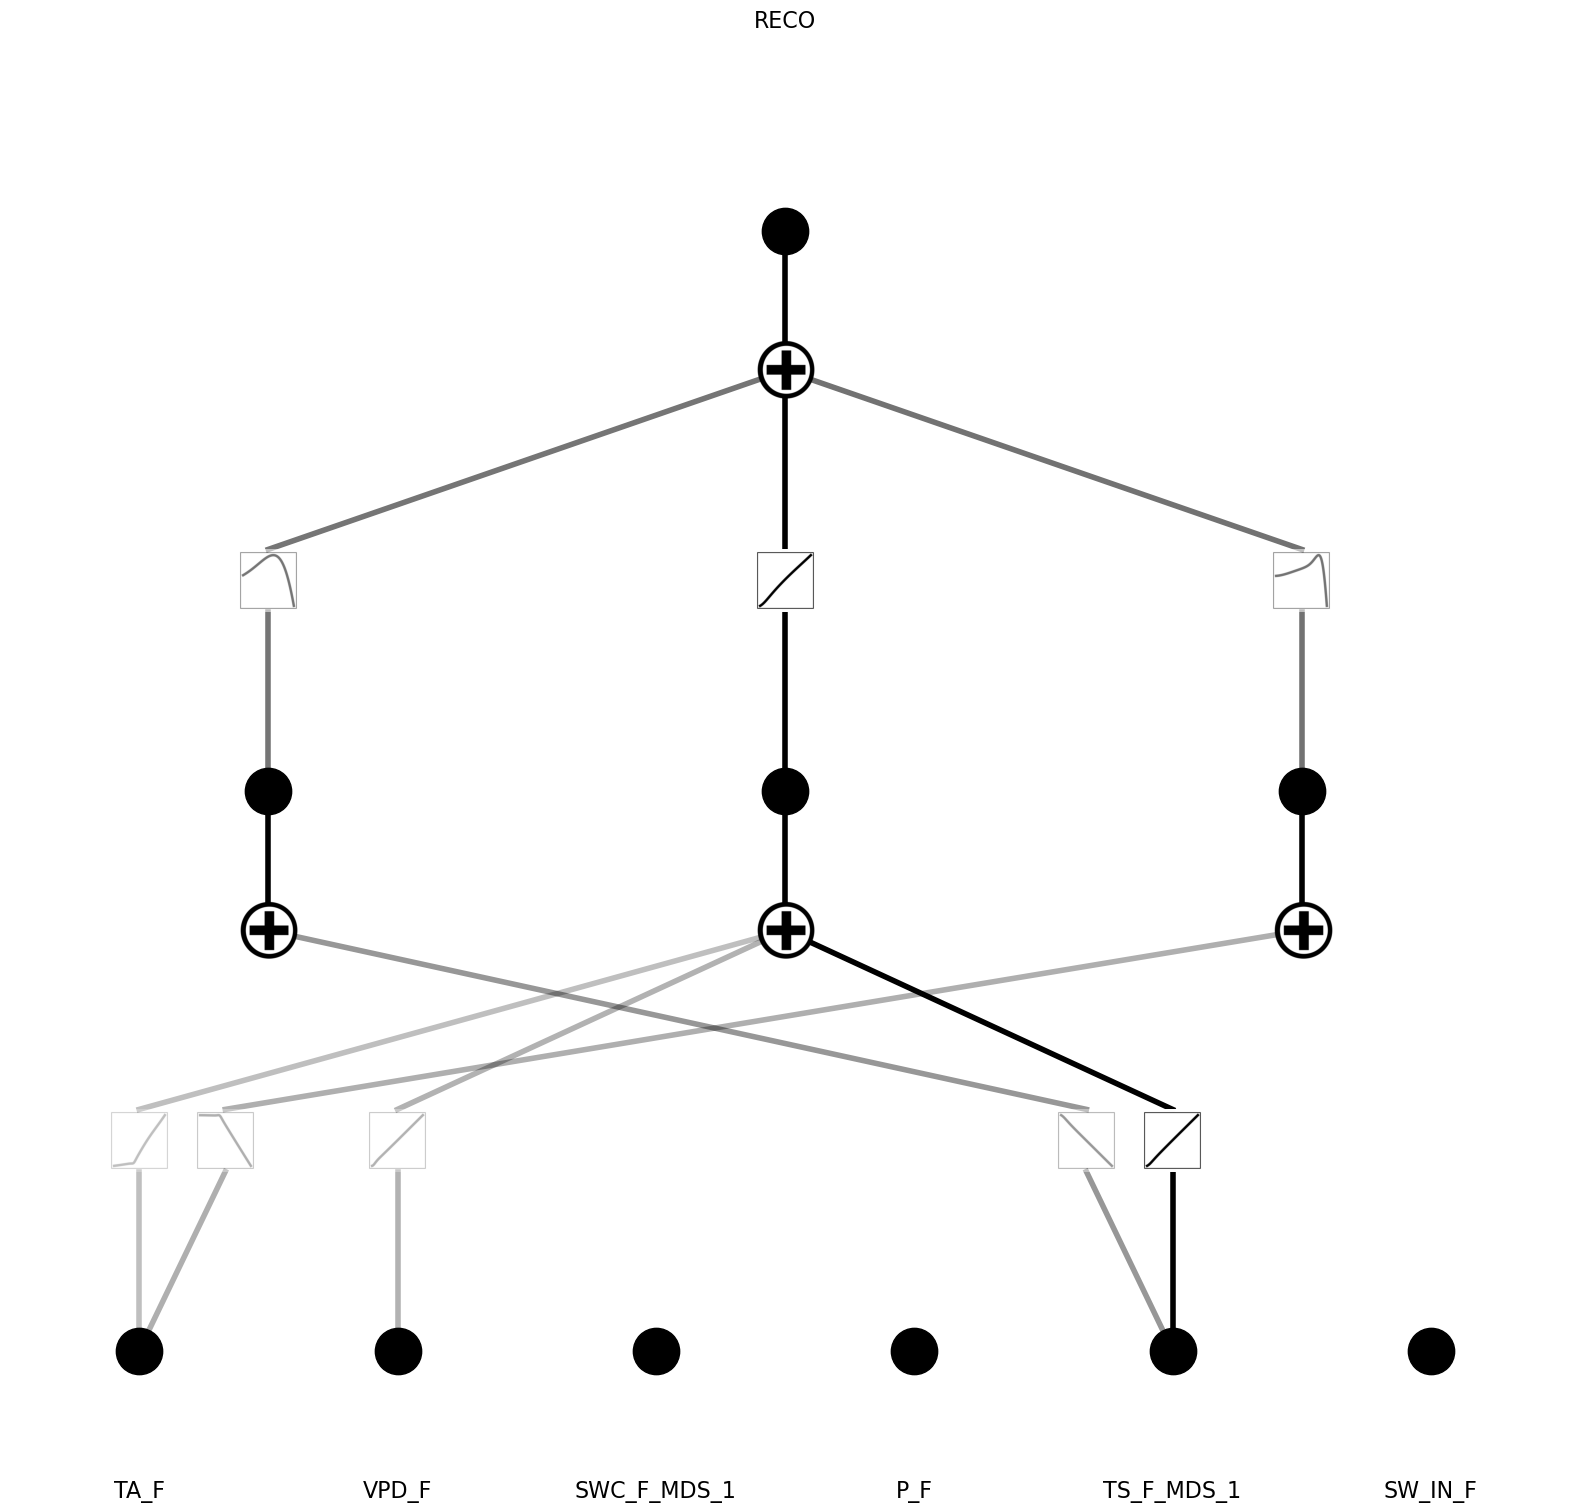

In [38]:
model.plot(beta=5, scale=2.0, in_vars=list(feature_dict.values()), out_vars=['RECO'], varscale=0.2)